In [1]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

import pandas as pd

train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')
merged_df = train_transaction.merge(train_identity, on='TransactionID', how='left')

In [2]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Creating a deep copy of the merged dataset
df = merged_df.copy(deep=True)

### A deep copy of the merged dataset was created to preserve the original raw data. This helps maintain data integrity during preprocessing, feature engineering, encoding, and model development, while also allowing easier debugging, visualization, and interpretation later in the project.

In [3]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

print(df.columns)
print(f"Shape: {df.shape}")
print("Data Types:")
print(df.dtypes)
print("First 10 rows of the merged dataset:")
print(df.head(10))

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)
Shape: (590540, 434)
Data Types:
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float64
ProductCD          object
                   ...   
id_36              object
id_37              object
id_38              object
DeviceType         object
DeviceInfo         object
Length: 434, dtype: object
First 10 rows of the merged dataset:
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        29870

In [4]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Count fraud vs non-fraud transactions
fraud_counts = df['isFraud'].value_counts()

print("Class Distribution:")
print(fraud_counts)

print("\nClass Percentage:")
print(merged_df['isFraud'].value_counts(normalize=True) * 100)

Class Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Class Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


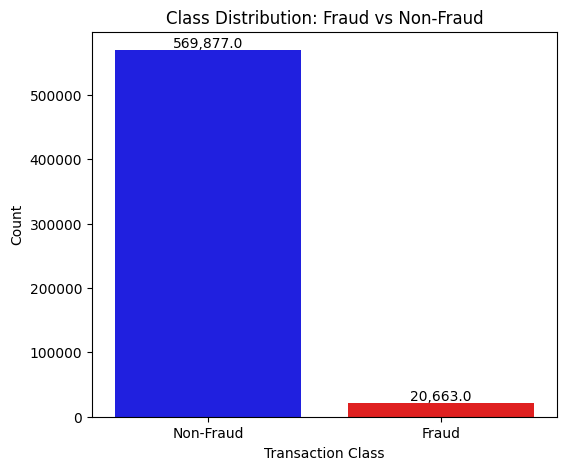

In [86]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Visualizing fraud vs non-fraud transactions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='isFraud',
    hue='isFraud',
    palette=['blue', 'red'],  # First color for 0, second color for 1
    legend=False
)


plt.title('Class Distribution: Fraud vs Non-Fraud')
plt.xlabel('Transaction Class')
plt.ylabel('Count')

#Adding values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks([0,1], ['Non-Fraud', 'Fraud'])

plt.show()

### Insight:

    The dataset is highly imbalanced, with fraudulent transactions representing only a very small percentage of the total transactions. This creates a challenging classification problem because machine learning models may become biased toward predicting the majority non-fraud class. Therefore,metrics such as Recall, F1-score, and PR-AUC become more important than overall accuracy.

In [6]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Calculating missing values for each column
missing_values = df.isnull().sum()

#Calculating missing percentage
missing_percent = (missing_values / len(df)) * 100

#Creating a summary dataframe
missing_df = pd.DataFrame({
    'MissingValues': missing_values,
    'MissingPercentage': missing_percent
})

#Sorting by highest missing percentage
missing_df = missing_df.sort_values(
    by='MissingPercentage',
    ascending=False
)

#Displaying top columns with missing values
missing_df.head(20)

,MissingValues,MissingPercentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


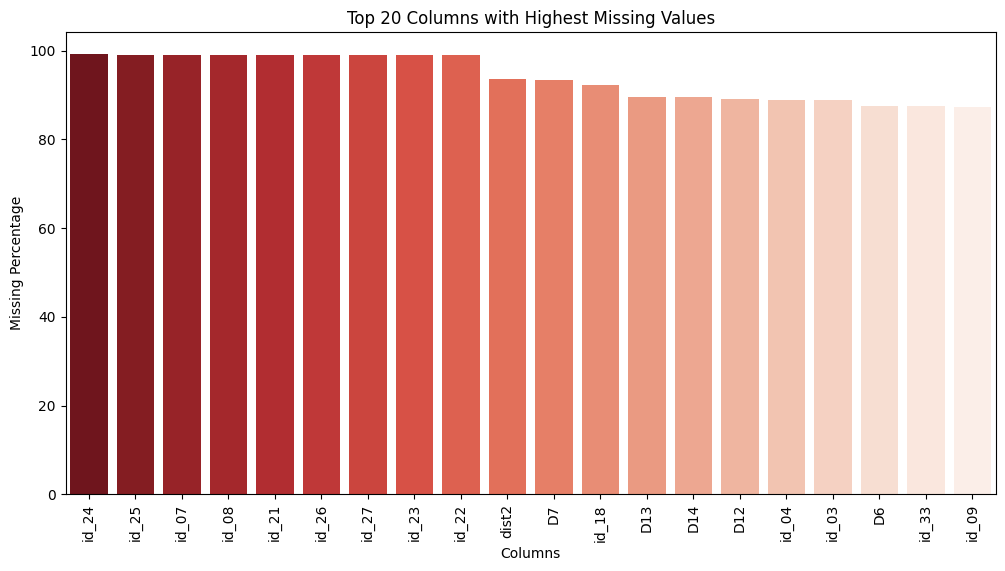

In [88]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Visualizing top 20 columns with highest missing values
top_missing = missing_df.head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_missing.index,
    y=top_missing['MissingPercentage'],
    hue=top_missing.index,
    legend=False,
    palette='Reds_r'
)

plt.xticks(rotation=90)

plt.ylabel('Missing Percentage')
plt.xlabel('Columns')

plt.title('Top 20 Columns with Highest Missing Values')

plt.show()

In [8]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Identifying columns with more than 50% missing values
cols_to_drop = missing_df[
    missing_df['MissingPercentage'] > 50
].index

print("Number of columns to remove:", len(cols_to_drop))

Number of columns to remove: 214


In [9]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Dropping columns with excessive missing values
df.drop(columns=cols_to_drop, inplace=True)
print("Updated dataset shape:", df.shape)

Updated dataset shape: (590540, 220)


### Insight:

    Columns containing more than 50% missing values were removed to reduce dataset sparsity and improve overall data quality. This helps minimize noise, lower computational complexity, and improve the reliability of subsequent machine learning models.

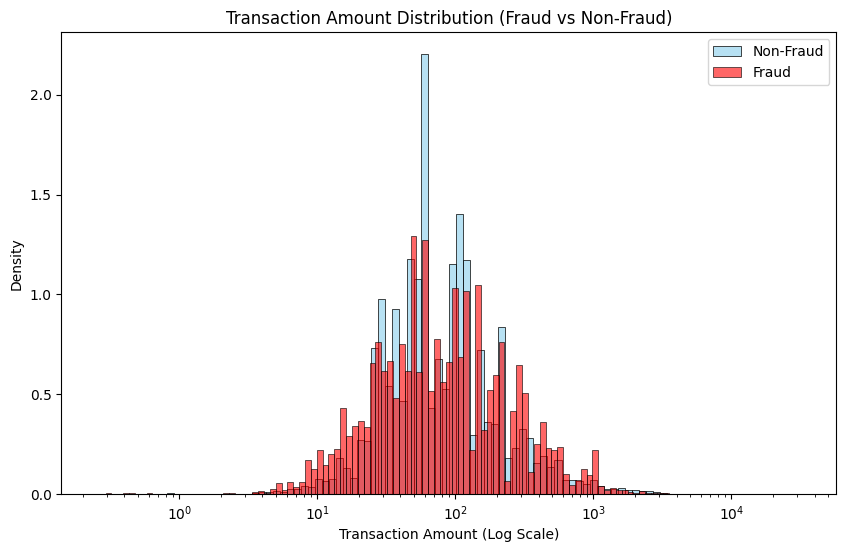

In [10]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Plotting Transaction Amount distribution for fraud vs non-fraud transactions
plt.figure(figsize=(10,6))

#Non-fraud transactions
sns.histplot(
    data=df[df['isFraud'] == 0],
    x='TransactionAmt',
    bins=100,
    color='skyblue',
    label='Non-Fraud',
    log_scale=True,
    stat='density',
    alpha=0.6
)

#Fraud transactions
sns.histplot(
    data=df[df['isFraud'] == 1],
    x='TransactionAmt',
    bins=100,
    color='red',
    label='Fraud',
    log_scale=True,
    stat='density',
    alpha=0.6
)

plt.title('Transaction Amount Distribution (Fraud vs Non-Fraud)')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Density')

plt.legend()

plt.show()

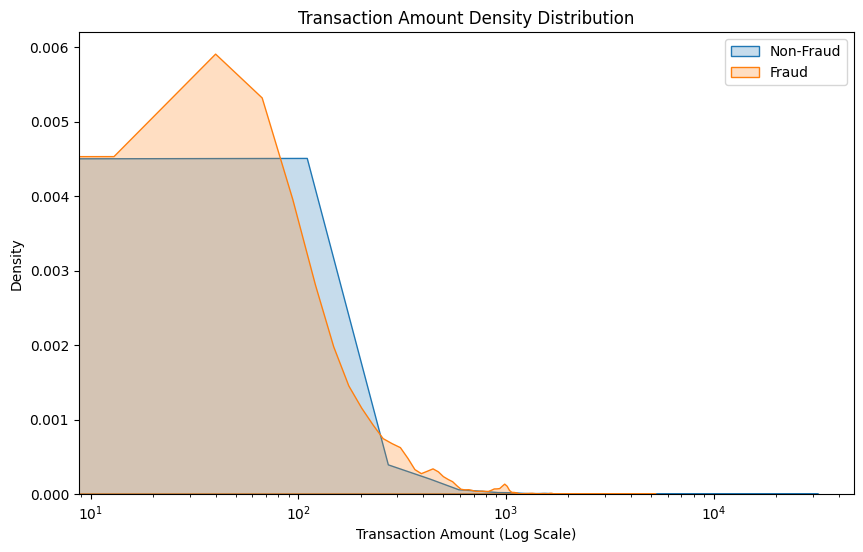

In [11]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df[df['isFraud']==0],
    x='TransactionAmt',
    label='Non-Fraud',
    fill=True
)

sns.kdeplot(
    data=df[df['isFraud']==1],
    x='TransactionAmt',
    label='Fraud',
    fill=True
)

plt.xscale('log')

plt.title('Transaction Amount Density Distribution')
plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Density')

plt.legend()

plt.show()

In [14]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Selecting numerical columns
numerical_cols = df.select_dtypes(
    include=['int64', 'float64']
)

#Computing correlation with target variable
corr_with_target = numerical_cols.corr()['isFraud']

#Selecting top 20 correlated features
top_features = corr_with_target.abs()\
    .sort_values(ascending=False)\
    .head(20)\
    .index

In [15]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Creating correlation matrix for top features
top_corr_matrix = numerical_cols[top_features].corr()

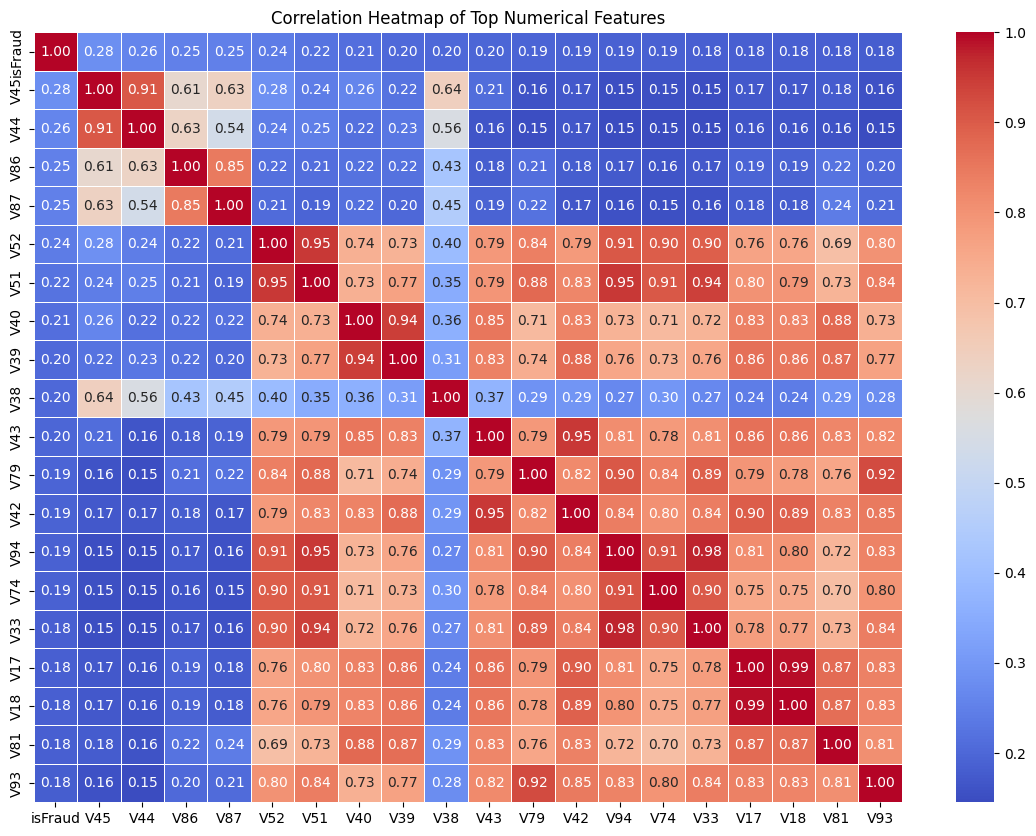

In [16]:
#TASK 1 — Data Loading, Merging & Exploratory Analysis

#Plotting correlation heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    top_corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Top Numerical Features')

plt.show()

In [17]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Separating numerical and categorical columns
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

cat_cols = df.select_dtypes(
    include=['object']
).columns

In [18]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Imputing numerical columns using median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [19]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Imputing categorical columns using mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [20]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Checking total remaining missing values
total_missing = df.isnull().sum().sum()
print("Total Remaining Missing Values:", total_missing)

#Checking missing values column-wise
remaining_missing = df.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print(remaining_missing)

Total Remaining Missing Values: 0
Series([], dtype: int64)


In [21]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Applying Label Encoding to categorical columns
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

### Why Label Encoding Was Chosen

    The IEEE-CIS dataset contains several high-cardinality categorical features such as browser information, device identifiers, and identity-related attributes. Applying one-hot encoding to such features would significantly increase dimensionality and computational complexity. Therefore, label encoding was selected as a memory-efficient and scalable encoding strategy suitable for tree-based machine learning models.

In [22]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Displaying sample encoded data
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,4,13926,361.0,150.0,1,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,4,2755,404.0,150.0,2,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,4,4663,490.0,150.0,3,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,4,18132,567.0,150.0,2,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,1,4497,514.0,150.0,2,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Checking remaining categorical columns
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [ ]:
#All categorical features have been successfully converted into numerical format for machine learning model compatibility.

In [24]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Defragmenting dataframe after preprocessing operations
df = df.copy()

In [25]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Creating transaction amount ratio feature
mean_amt = df['TransactionAmt'].mean()

df['AmtToMeanRatio'] = (
    df['TransactionAmt'] / mean_amt
)

### Feature Engineering — AmtToMeanRatio

    This feature compares each transaction amount against the overall average transaction amount in the dataset. Transactions with unusually high ratios may indicate abnormal or suspicious spending behavior, making this feature potentially useful for fraud detection.

In [26]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Extracting hour of day from TransactionDT
df['HourOfDay'] = (
    (df['TransactionDT'] / 3600) % 24
).astype(int)

### Feature Engineering — HourOfDay

    The HourOfDay feature was derived from the transaction timestamp to capture temporal transaction behavior. Fraudulent activities often occur during unusual or low-monitoring hours, making transaction timing an important predictive signal.

In [27]:
print('DeviceType' in df.columns)
print('DeviceInfo' in df.columns)

False
False


### DeviceType and DeviceInfo had: >50% missing values and got removed during: df.drop(columns=cols_to_drop, inplace=True)

In [28]:
#Checking unique values in DeviceType and DeviceInfo
print(merged_df['DeviceType'].value_counts(dropna=False))
print(merged_df['DeviceInfo'].value_counts(dropna=False))

DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64
DeviceInfo
NaN            471874
Windows         47722
iOS Device      19782
MacOS           12573
Trident/7.0      7440
                ...  
5044A               1
LG-D373             1
Bolt                1
LG-K350             1
SM-G920T            1
Name: count, Length: 1787, dtype: int64


In [29]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Creating DeviceRisk feature
import numpy as np

df['DeviceRisk'] = np.where(

    merged_df['DeviceType'].isnull() |

    merged_df['DeviceInfo'].isnull() |

    (merged_df['DeviceType'] == 'mobile'),

    1,

    0
)

### Risk Rules
    A transaction becomes risky if: DeviceType missing OR DeviceInfo missing OR mobile device used
    Because:
        1. fraudsters often hide/spoof device information
        2. mobile transactions are slightly harder to verify
        3. missing metadata itself is suspicious

### Feature Engineering - DeviceRisk
    A binary DeviceRisk feature was engineered using DeviceType and DeviceInfo. Transactions with missing device metadata or mobile-based activity were categorized as higher risk, as incomplete device information and mobile transaction patterns are commonly associated with suspicious online behavior in fraud detection systems.

In [30]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

df[[
    'TransactionAmt',
    'AmtToMeanRatio',
    'HourOfDay',
    'DeviceRisk'
]].head()

,TransactionAmt,AmtToMeanRatio,HourOfDay,DeviceRisk
0,68.5,0.507305,0,1
1,29.0,0.214772,0,1
2,59.0,0.436949,0,1
3,50.0,0.370296,0,1
4,50.0,0.370296,0,1


In [31]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Separating features and target variable
X = df.drop('isFraud', axis=1)

y = df['isFraud']

### Feature-Target Separation

    The dataset was divided into input features (X) and the target variable (y) to prepare the data for supervised machine learning model training.

In [32]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

from sklearn.model_selection import train_test_split

#Performing stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Stratified Train-Test Split

    An 80/20 stratified train-test split was applied to ensure that both training and testing datasets preserve the original fraud class distribution. Stratification is especially important in imbalanced classification problems such as fraud detection.

In [33]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Checking class distribution before SMOTE
print("Class Distribution Before SMOTE:")
print(y_train.value_counts())

print("\nClass Ratio Before SMOTE:")
print(y_train.value_counts(normalize=True))

Class Distribution Before SMOTE:
isFraud
0    455902
1     16530
Name: count, dtype: int64

Class Ratio Before SMOTE:
isFraud
0    0.965011
1    0.034989
Name: proportion, dtype: float64


### Train-Test Split
    → Apply SMOTE on training set only
    → Train model
    → Evaluate on untouched test set

    SMOTE is an oversampling technique used to handle class imbalance by generating synthetic samples for the minority class instead of duplicating existing observations. This helps machine learning models learn minority class patterns more effectively and improves fraud detection performance.

In [ ]:
%pip install imbalanced-learn

In [34]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

from imblearn.over_sampling import SMOTE

#Applying SMOTE to balance training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

### SMOTE for Class Imbalance Handling

    SMOTE (Synthetic Minority Oversampling Technique) was applied only to the training dataset to address severe class imbalance. The technique generates synthetic fraud samples to improve the model’s ability to learn minority class patterns without affecting the integrity of the test dataset.

In [35]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Checking class distribution after SMOTE
print("Class Distribution After SMOTE:")
print(y_train_smote.value_counts())

print("\nClass Ratio After SMOTE:")
print(y_train_smote.value_counts(normalize=True))

Class Distribution After SMOTE:
isFraud
0    455902
1    455902
Name: count, dtype: int64

Class Ratio After SMOTE:
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64


### Insight:

    After applying SMOTE, the class distribution became balanced, allowing the machine learning models to learn fraud-related patterns more effectively. This helps improve minority class detection performance and reduces model bias toward legitimate transactions.

In [36]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

from sklearn.preprocessing import RobustScaler

#Applying RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

### Feature Scaling Using RobustScaler

    RobustScaler was applied to normalize feature distributions while reducing the influence of extreme outliers commonly present in fraud detection datasets. The scaler was fitted only on the training data and subsequently applied to the test data to avoid data leakage.

In [37]:
#TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering

#Converting scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

### Converting Scaled Arrays Back to DataFrames
    After feature scaling, the transformed NumPy arrays were converted back into Pandas DataFrames to preserve original feature names and column structure. This improves interpretability, simplifies debugging, and ensures compatibility with visualization and Explainable AI techniques such as SHAP analysis.

In [ ]:
!pip install lightgbm

In [38]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Importing machine learning models and evaluation metrics
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

### Model Selection

    Three different models were selected for fraud detection:

    1. LightGBM for efficient gradient boosting on large-scale tabular data
    2. XGBoost for powerful ensemble-based classification performance
    3. Isolation Forest as an anomaly detection approach suitable for rare fraud events

## Evaluation Metrics Explanation

* **Accuracy** → Measures the overall percentage of correctly classified transactions.

* **Precision** → Indicates how many transactions predicted as fraud were actually fraudulent.

* **Recall** → Measures how many actual fraud transactions were successfully detected by the model.

* **F1-Score** → Provides a balanced measure of precision and recall, especially useful for imbalanced datasets.

* **ROC-AUC** → Evaluates the model’s ability to distinguish between fraudulent and legitimate transactions across different classification thresholds.

* **PR-AUC** → Measures the trade-off between precision and recall and is more informative for highly imbalanced fraud detection problems.


In [39]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Training LightGBM classifier

lgbm_model = LGBMClassifier(
    random_state=42,
    verbose = -1
)
lgbm_model.fit(
    X_train_scaled,
    y_train_smote
)

#Generating predictions for LightGBM
y_pred_lgbm = lgbm_model.predict(X_test_scaled)
y_prob_lgbm = lgbm_model.predict_proba(X_test_scaled)[:,1]

#Evaluating LightGBM model
print("LightGBM Performance:\n")
print("Accuracy:",accuracy_score(y_test, y_pred_lgbm))
print("Precision:",precision_score(y_test, y_pred_lgbm))
print("Recall:",recall_score(y_test, y_pred_lgbm))
print("F1 Score:",f1_score(y_test, y_pred_lgbm))
print("ROC-AUC:",roc_auc_score(y_test, y_prob_lgbm))
print("PR-AUC:",average_precision_score(y_test, y_prob_lgbm))

LightGBM Performance:

Accuracy: 0.9746841873539472
Precision: 0.7615560640732265
Recall: 0.4026131139608033
F1 Score: 0.5267489711934157
ROC-AUC: 0.899019278224735
PR-AUC: 0.5565773254263492


### Insight:
    
    The LightGBM model achieved strong overall classification performance with a ROC-AUC score of approximately 0.90, indicating excellent discrimination between fraudulent and legitimate transactions. The model demonstrated high precision, meaning predicted fraud cases were often correct. However, recall remained moderate, suggesting that some fraudulent transactions were still missed. This highlights the importance of threshold optimization in fraud detection systems where minimizing false negatives is critical.

In [40]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Training XGBoost classifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(
    X_train_scaled,
    y_train_smote
)

#Generating predictions for XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

#Evaluating XGBoost model
print("XGBoost Performance:\n")
print("Accuracy:",accuracy_score(y_test, y_pred_xgb))
print("Precision:",precision_score(y_test, y_pred_xgb))
print("Recall:",recall_score(y_test, y_pred_xgb))
print("F1 Score:",f1_score(y_test, y_pred_xgb))
print("ROC-AUC:",roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:",average_precision_score(y_test, y_prob_xgb))

XGBoost Performance:

Accuracy: 0.9786720628577235
Precision: 0.8490484429065744
Recall: 0.47495765787563515
F1 Score: 0.6091543832428239
ROC-AUC: 0.9244024080439661
PR-AUC: 0.6587329915170279


### Why eval_metric='logloss' was used

    The logloss evaluation metric was specified in XGBoost to measure prediction error based on predicted probabilities, making it suitable for binary fraud classification tasks.

### Insight:

    The XGBoost model outperformed LightGBM across all major evaluation metrics, including Precision, Recall, F1-Score, ROC-AUC, and PR-AUC. The model demonstrated stronger fraud discrimination capability and improved minority-class detection performance, making it the best-performing supervised learning model in this analysis so far.

In [41]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Training Isolation Forest model

iso_model = IsolationForest(
    contamination=0.035,
    random_state=42
)
iso_model.fit(X_train_scaled)

#Generating predictions for Isolation Forest
y_pred_iso = iso_model.predict(X_test_scaled)

#Converting predictions
y_pred_iso = np.where(
    y_pred_iso == -1,
    1,
    0
)
iso_scores = -iso_model.decision_function(
    X_test_scaled
)

#Evaluating Isolation Forest model
print("Isolation Forest Performance:\n")
print("Accuracy:",accuracy_score(y_test, y_pred_iso))
print("Precision:",precision_score(y_test, y_pred_iso))
print("Recall:",recall_score(y_test, y_pred_iso))
print("F1 Score:",f1_score(y_test, y_pred_iso))
print("ROC-AUC:",roc_auc_score(y_test, iso_scores))
print("PR-AUC:",average_precision_score(y_test, iso_scores))

Isolation Forest Performance:

Accuracy: 0.9525095675144782
Precision: 0.12269938650306748
Recall: 0.05806919912896201
F1 Score: 0.0788306782722943
ROC-AUC: 0.6212659346524082
PR-AUC: 0.06223951027801672


### Note:
    Unlike supervised classifiers such as XGBoost and LightGBM, Isolation Forest is an unsupervised anomaly detection algorithm that does not directly generate fraud probabilities. Instead, anomaly scores obtained from the decision_function were used to compute ROC-AUC and PR-AUC metrics for comparative evaluation.

### Insight:

    Isolation Forest demonstrated significantly weaker fraud detection performance compared to supervised boosting models. Since Isolation Forest relies on anomaly detection rather than learning labeled fraud patterns directly, it struggled to identify complex and subtle fraudulent transactions in the highly imbalanced IEEE-CIS dataset. This highlights the superiority of supervised ensemble models for large-scale fraud classification tasks.

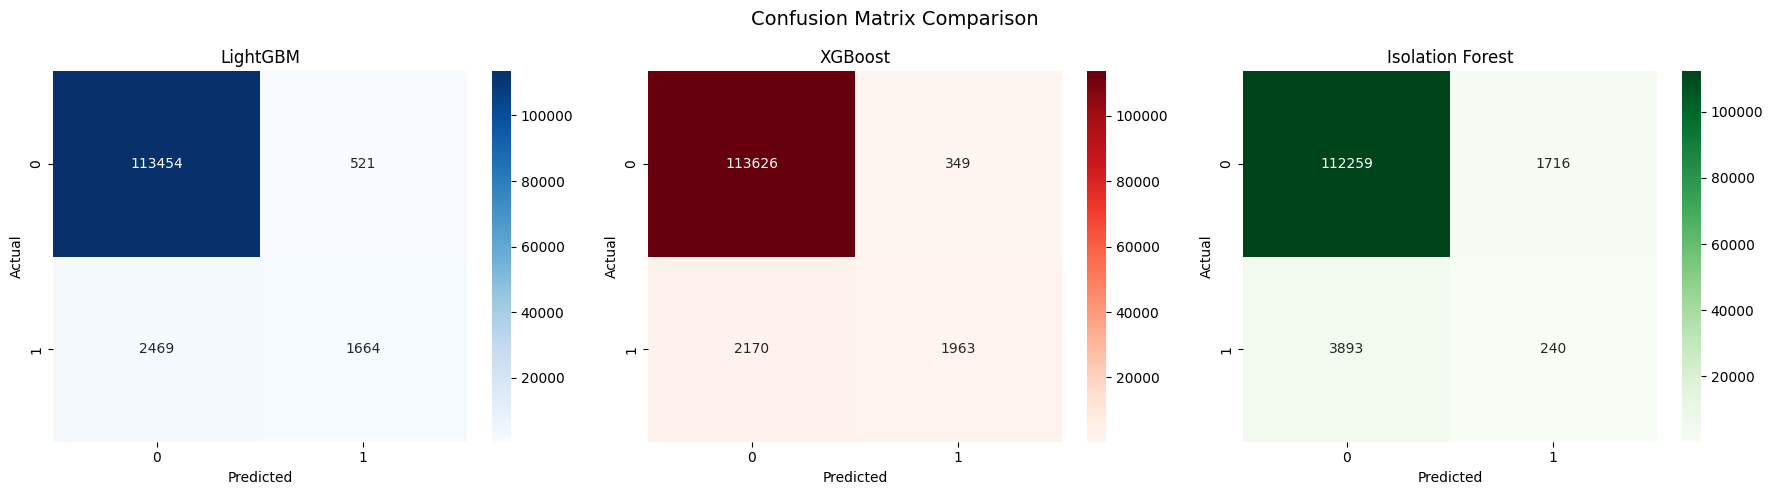

In [42]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Computing confusion matrices

cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm
)

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

cm_iso = confusion_matrix(
    y_test,
    y_pred_iso
)

#Plotting confusion matrices
fig, axes = plt.subplots(
    1, 3,
    figsize=(18,5)
)

models_info = [
    (cm_lgbm, 'LightGBM', 'Blues'),
    (cm_xgb, 'XGBoost', 'Reds'),
    (cm_iso, 'Isolation Forest', 'Greens')
]

for ax, (cm, title, cmap) in zip(axes, models_info):

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle(
    'Confusion Matrix Comparison',
    fontsize=14
)

plt.tight_layout()
plt.show()

### Insight:

    The confusion matrices highlight each model’s ability to correctly identify fraudulent transactions while minimizing false positives and false negatives. In fraud detection, reducing false negatives is particularly important because missed fraud cases may result in significant financial losses.

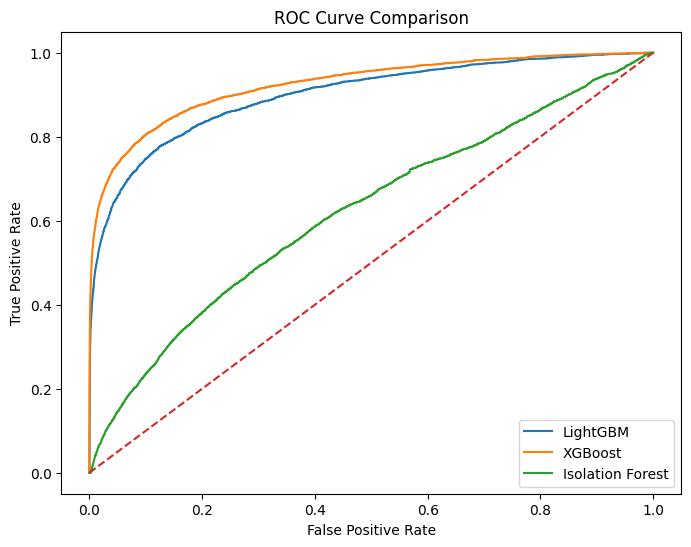

In [90]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Plotting ROC Curve for model comparison

from sklearn.metrics import roc_curve

#Calculating ROC values
fpr_lgbm, tpr_lgbm, _ = roc_curve(
    y_test,
    y_prob_lgbm
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

fpr_iso, tpr_iso, _ = roc_curve(
    y_test,
    iso_scores
)
#Plotting ROC curves
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lgbm,
    tpr_lgbm,
    label='LightGBM'
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label='XGBoost'
)

plt.plot(
    fpr_iso,
    tpr_iso,
    label='Isolation Forest'
)
#Reference diagonal line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

### Insight:

    The ROC curve illustrates the ability of the models to distinguish between fraudulent and legitimate transactions across different thresholds. The XGBoost model demonstrated stronger class separation capability, as reflected by its higher ROC-AUC score and curve performance.

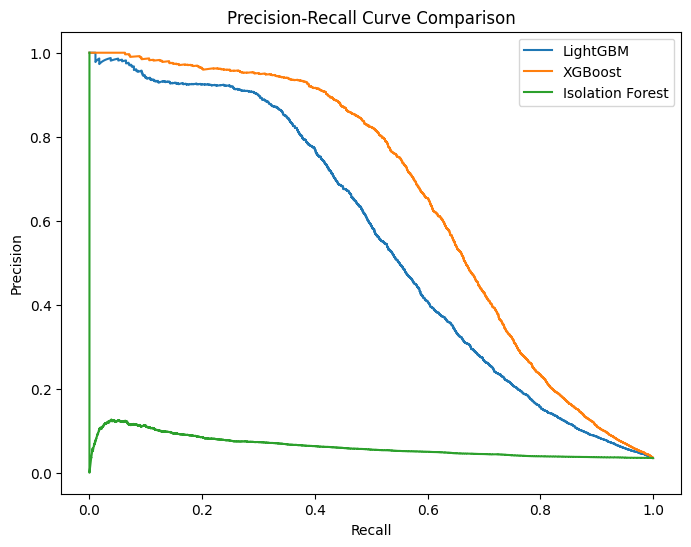

In [91]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Plotting Precision-Recall Curve

from sklearn.metrics import precision_recall_curve

#Calculating PR values
precision_lgbm, recall_lgbm, _ = precision_recall_curve(
    y_test,
    y_prob_lgbm
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

precision_iso, recall_iso, _ = precision_recall_curve(
    y_test,
    iso_scores
)

#Plotting PR curves
plt.figure(figsize=(8,6))

plt.plot(
    recall_lgbm,
    precision_lgbm,
    label='LightGBM'
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label='XGBoost'
)

plt.plot(
    recall_iso,
    precision_iso,
    label='Isolation Forest'
)

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.title('Precision-Recall Curve Comparison')

plt.legend()

plt.show()

### Insight:

    The Precision-Recall curve provides a clearer evaluation of fraud detection performance on imbalanced datasets. XGBoost achieved a superior balance between precision and recall, demonstrating stronger capability in identifying fraudulent transactions while minimizing false fraud alerts.

## Isolation Forest ROC and Precision-Recall Analysis

    ROC and Precision-Recall curves were generated for the Isolation Forest model using anomaly scores produced by the decision function. Since Isolation Forest is an unsupervised anomaly detection algorithm, these scores represent the relative abnormality of transactions rather than direct fraud probabilities.

    The ROC curve evaluates the model’s ability to distinguish fraudulent and non-fraudulent transactions across multiple anomaly thresholds, while the Precision-Recall curve provides additional insight into fraud detection performance under class imbalance conditions.

### Why threshold optimization?
    Currently models use: default threshold = 0.5
    Meaning:
    if probability > 0.5:
    fraud
    But fraud detection often requires: lower thresholds to catch more frauds.

In [45]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Finding optimal threshold using F1-score

thresholds = np.arange(
    0.1,
    1.0,
    0.05
)

f1_scores = []

for threshold in thresholds:

    y_pred_threshold = (
        y_prob_xgb >= threshold
    ).astype(int)

    score = f1_score(
        y_test,
        y_pred_threshold
    )

    f1_scores.append(score)

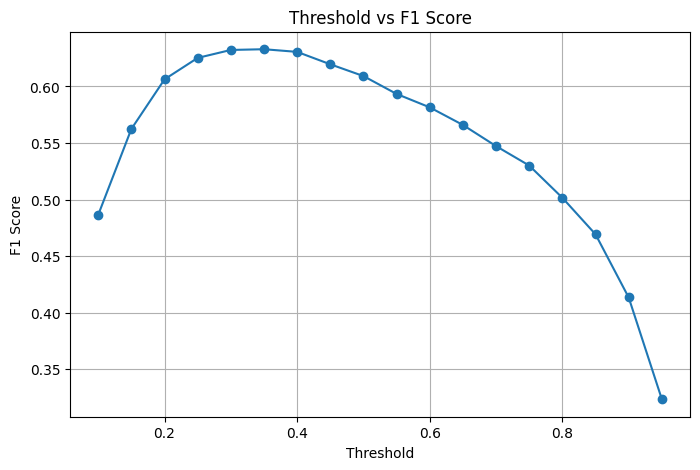

In [46]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Plotting threshold vs F1-score

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f1_scores,
    marker='o'
)

plt.xlabel('Threshold')

plt.ylabel('F1 Score')

plt.title('Threshold vs F1 Score')

plt.grid(True)

plt.show()

In [47]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Finding best threshold

best_threshold = thresholds[
    np.argmax(f1_scores)
]

best_f1 = max(f1_scores)

print("Best Threshold:", best_threshold)

print("Best F1 Score:", best_f1)

Best Threshold: 0.3500000000000001
Best F1 Score: 0.6328794047451917


### Insight:
    Threshold optimization revealed that the default probability threshold of 0.5 was not optimal for fraud detection. Lowering the threshold to approximately 0.35 improved the balance between Precision and Recall, resulting in a higher F1-score and more effective identification of fraudulent transactions.

### Threshold Optimization
    Threshold optimization was performed only for the XGBoost model because it achieved the strongest overall fraud detection performance among the evaluated models. Since XGBoost generates calibrated fraud probabilities, adjusting the classification threshold enabled better balance between precision and recall in the highly imbalanced fraud detection setting.

### Hyperparameter Tuning using optuna
        For the best model: XGBoost
### Why Optuna?
        Optuna is an advanced hyperparameter optimization framework that efficiently searches the parameter space using intelligent trial-based optimization instead of exhaustive brute-force search. Compared to traditional tuning methods, Optuna reduces computational overhead while improving optimization efficiency, making it suitable for large-scale fraud detection datasets.

In [48]:
print(X_train_scaled.shape)
print(y_train_smote.shape)

(911804, 222)
(911804,)


In [49]:
#Creating smaller subset for Optuna tuning

X_tune = X_train_scaled[:50000]
y_tune = y_train_smote[:50000]

In [50]:
print(X_tune.shape)
print(y_tune.shape)

(50000, 222)
(50000,)


### Creating a Representative Tuning Subset
    A representative subset of the scaled training data was created for hyperparameter tuning in order to reduce computational complexity and execution time. This approach enables efficient optimization while preserving the overall data distribution and fraud characteristics of the original dataset.

In [53]:
pip install optuna

   ---------------------------------------- 0.0/419.5 kB ? eta -:--:--
   --------------------------- ------------ 286.7/419.5 kB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 419.5/419.5 kB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/263.9 kB ? eta -:--:--
   ---------------------------------------- 263.9/263.9 kB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/78.5 kB ? eta -:--:--
   ---------------------------------------- 78.5/78.5 kB 4.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

In [52]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Defining Optuna objective function

def objective(trial):
    params = {

        'n_estimators': trial.suggest_int(
            'n_estimators',
            100,
            300
        ),

        'max_depth': trial.suggest_int(
            'max_depth',
            3,
            10
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.3
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.6,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.6,
            1.0
        ),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(
        **params
    )

    score = cross_val_score(
        model,

        X_tune,

        y_tune,

        cv=3,

        scoring='f1',

        n_jobs=-1
    ).mean()

    return score

In [53]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Creating Optuna study

study = optuna.create_study(
    direction='maximize'
)

#Running optimization

study.optimize(
    objective,
    n_trials=10
)

[I 2026-05-25 19:50:10,154] A new study created in memory with name: no-name-e88e73e1-f765-43a2-b2e7-2f143eae9ea2
[I 2026-05-25 19:50:35,519] Trial 0 finished with value: 0.5381714867981063 and parameters: {'n_estimators': 227, 'max_depth': 5, 'learning_rate': 0.2550199561771671, 'subsample': 0.9470281857724007, 'colsample_bytree': 0.7334371246726472}. Best is trial 0 with value: 0.5381714867981063.
[I 2026-05-25 19:50:51,571] Trial 1 finished with value: 0.5057781671310323 and parameters: {'n_estimators': 123, 'max_depth': 6, 'learning_rate': 0.13505330894956658, 'subsample': 0.817829979761488, 'colsample_bytree': 0.8463471330846624}. Best is trial 0 with value: 0.5381714867981063.
[I 2026-05-25 19:51:14,927] Trial 2 finished with value: 0.5465149945706071 and parameters: {'n_estimators': 298, 'max_depth': 7, 'learning_rate': 0.2202414219349562, 'subsample': 0.9928382115769415, 'colsample_bytree': 0.9476894937352296}. Best is trial 2 with value: 0.5465149945706071.
[I 2026-05-25 19:51

In [54]:
print("Best Parameters:\n")
print(study.best_params)
print("\nBest F1 Score:\n")
print(study.best_value)

Best Parameters:

{'n_estimators': 298, 'max_depth': 7, 'learning_rate': 0.2202414219349562, 'subsample': 0.9928382115769415, 'colsample_bytree': 0.9476894937352296}

Best F1 Score:

0.5465149945706071


### Note on Cross-Validation F1 Score During Optuna Tuning

    The F1-score observed during Optuna hyperparameter tuning was lower than the earlier baseline XGBoost evaluation score because tuning was performed using cross-validation on a smaller representative subset of the training data rather than the complete dataset.

    Cross-validation provides a stricter and more robust estimate of model generalization by repeatedly validating the model across multiple folds of unseen data. Additionally, the reduced tuning subset contained fewer fraud patterns and transaction variations compared to the full training dataset, which can naturally lead to lower intermediate validation scores during optimization.

In [55]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Training final tuned XGBoost model

xgb_tuned = XGBClassifier(

    **study.best_params,

    random_state=42,

    eval_metric='logloss'
)

xgb_tuned.fit(

    X_train_scaled,

    y_train_smote
)

#Generating predictions

y_pred_tuned = xgb_tuned.predict(
    X_test_scaled
)

y_prob_tuned = xgb_tuned.predict_proba(
    X_test_scaled
)[:,1]

In [56]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

#Evaluating tuned model

print("Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

print("Precision:",
      precision_score(y_test, y_pred_tuned))

print("Recall:",
      recall_score(y_test, y_pred_tuned))

print("F1 Score:",
      f1_score(y_test, y_pred_tuned))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_tuned))

print("PR-AUC:",
      average_precision_score(
          y_test,
          y_prob_tuned
      ))

Accuracy: 0.9832695499034781
Precision: 0.914329619669612
Recall: 0.5758528913622066
F1 Score: 0.7066508313539193
ROC-AUC: 0.9571203024761193
PR-AUC: 0.7820631518323751


In [58]:
#TASK 3 — Model Training, Comparison & Threshold Optimization

comparison_df = pd.DataFrame({

    'Metric': [

        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC',
        'PR-AUC'
    ],

    'Baseline XGBoost': [

        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_xgb)
    ],

    'Tuned XGBoost': [

      accuracy_score(y_test, y_pred_tuned),
      precision_score(y_test, y_pred_tuned),
      recall_score(y_test, y_pred_tuned),
      f1_score(y_test, y_pred_tuned),
      roc_auc_score(y_test, y_prob_tuned),
      average_precision_score(y_test,y_prob_tuned)
    ]
})
print(comparison_df)

      Metric  Baseline XGBoost  Tuned XGBoost
0   Accuracy          0.978672       0.983270
1  Precision          0.849048       0.914330
2     Recall          0.474958       0.575853
3   F1 Score          0.609154       0.706651
4    ROC-AUC          0.924402       0.957120
5     PR-AUC          0.658733       0.782063


### After identifying the optimal hyperparameters, the final tuned XGBoost model was retrained using the complete training dataset, resulting in substantial performance improvements across all major evaluation metrics.

In [ ]:
pip install shap

### Why SHAP?

    SHAP (SHapley Additive exPlanations) is an Explainable AI technique used to interpret machine learning predictions. It helps identify how each feature contributes to fraud predictions, making the model more transparent and trustworthy for real-world financial applications.

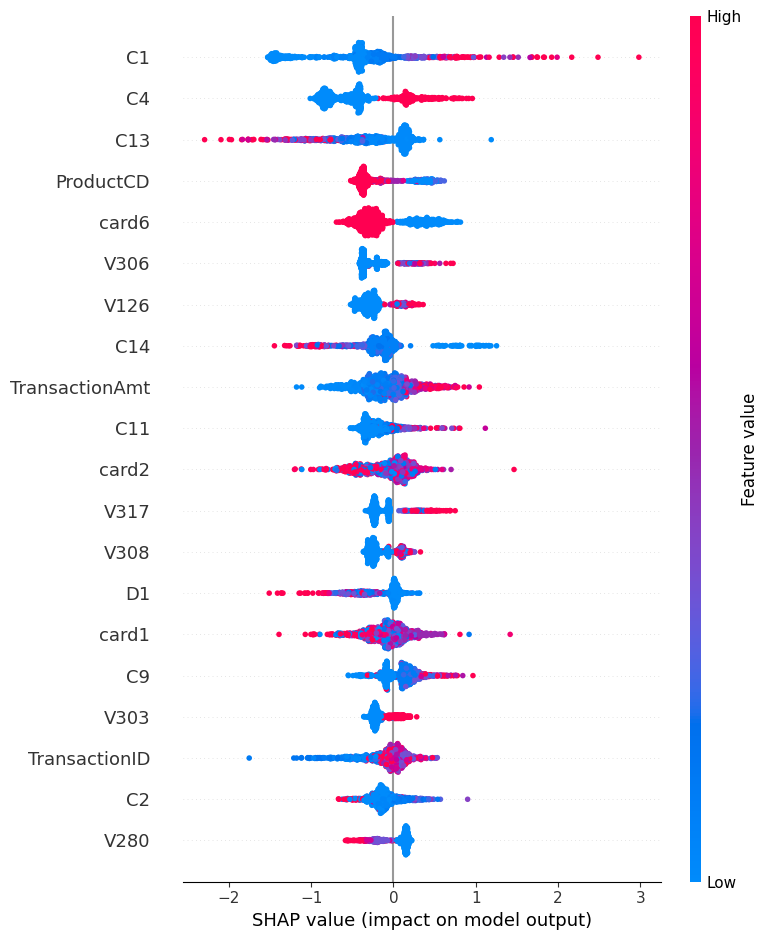

In [59]:
#TASK 4 — Explainable AI with SHAP Values

#Importing SHAP library
import shap

#Creating SHAP explainer
explainer = shap.TreeExplainer(
    xgb_tuned
)

#Taking smaller sample for SHAP analysis
X_shap = X_test_scaled[:1000]

#Generating SHAP values
shap_values = explainer.shap_values(
    X_shap
)

#Generating SHAP summary plot for top 20 features
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)

### Insight:

    The SHAP summary plot highlights the top 20 features contributing to fraud predictions across all sampled transactions. Features with larger SHAP magnitudes exert stronger influence on model decisions, enabling transparent interpretation of the factors driving fraudulent transaction detection.

In [60]:
#TASK 4 — Explainable AI with SHAP Values

#Generating SHAP explanation values
shap_explanation = explainer(
    X_shap
)

### shap_values alone: stores raw SHAP numbers
    But: shap_explanation contains:
        feature names
        base values
        prediction contributions
    required for waterfall plots.

In [61]:
#TASK 4 — Explainable AI with SHAP Values

#Finding fraud transaction

fraud_index = np.where(
    y_prob_tuned[:1000] > 0.9
)[0][0]

print("Fraud Transaction Index:",
      fraud_index)

Fraud Transaction Index: 58


In [62]:
#TASK 4 — Explainable AI with SHAP Values

#Finding borderline transaction

borderline_index = np.argmin(
    np.abs(y_prob_tuned[:1000] - 0.5)
)

print("Borderline Transaction Index:",
      borderline_index)

Borderline Transaction Index: 207


In [63]:
#TASK 4 — Explainable AI with SHAP Values

#Finding legitimate transaction

legit_index = np.where(
    y_prob_tuned[:1000] < 0.1
)[0][0]

print("Legitimate Transaction Index:",
      legit_index)

Legitimate Transaction Index: 0


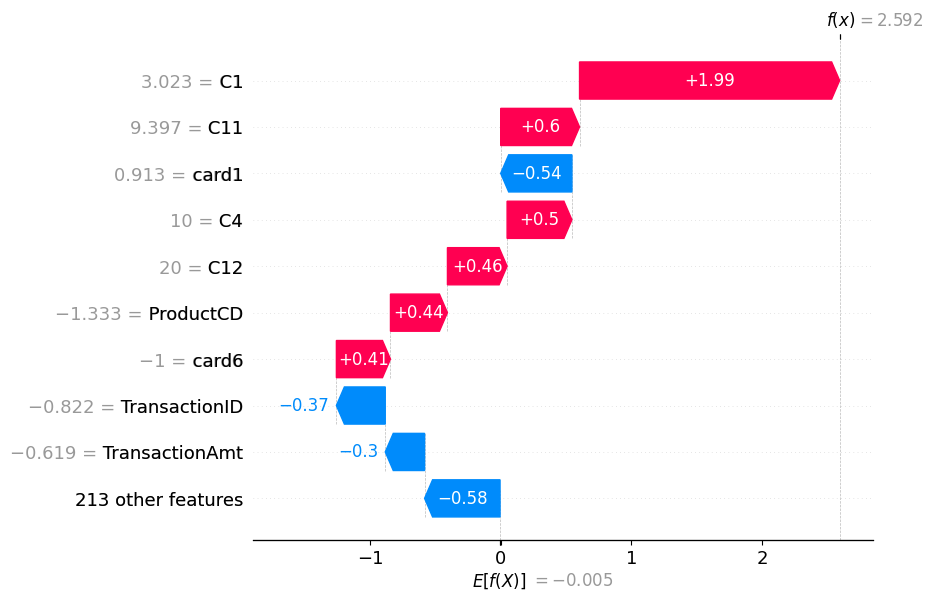

In [64]:
#TASK 4 — Explainable AI with SHAP Values

#Generating SHAP waterfall plot for fraud case

shap.plots.waterfall(
    shap_explanation[fraud_index]
)

### Fraud Transaction Explanation
    The waterfall plot illustrates the individual feature contributions that pushed the model toward predicting the transaction as fraudulent. Positive SHAP contributions increased fraud probability, while negative contributions reduced it. The combined influence of high-risk features resulted in a strong fraud prediction.

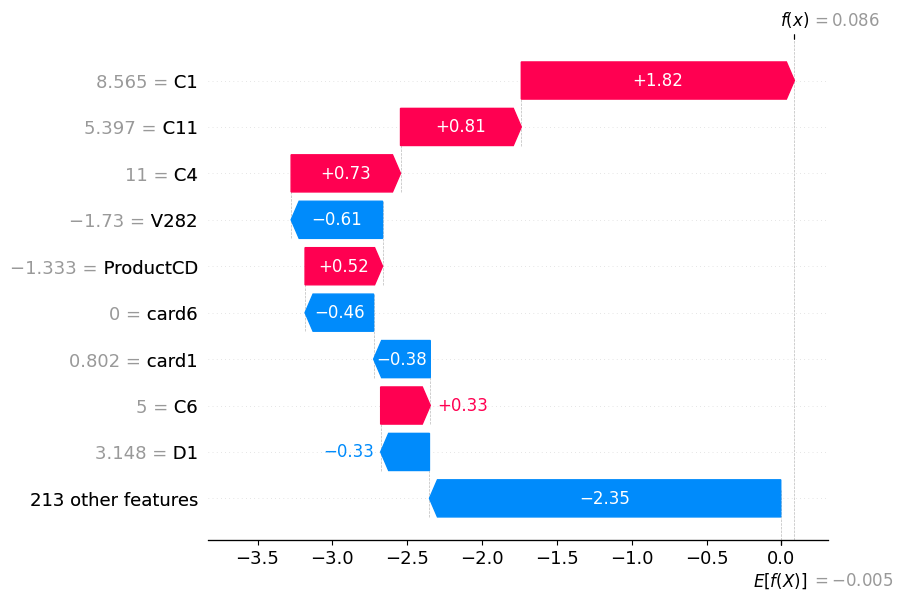

In [65]:
#TASK 4 — Explainable AI with SHAP Values

#Generating SHAP waterfall plot for borderline transaction

shap.plots.waterfall(
    shap_explanation[borderline_index]
)

### Borderline Transaction Explanation
    The borderline transaction displayed mixed feature contributions, with some features increasing fraud probability and others reducing it. This resulted in prediction uncertainty near the classification threshold, demonstrating the model’s sensitivity to competing transaction characteristics.

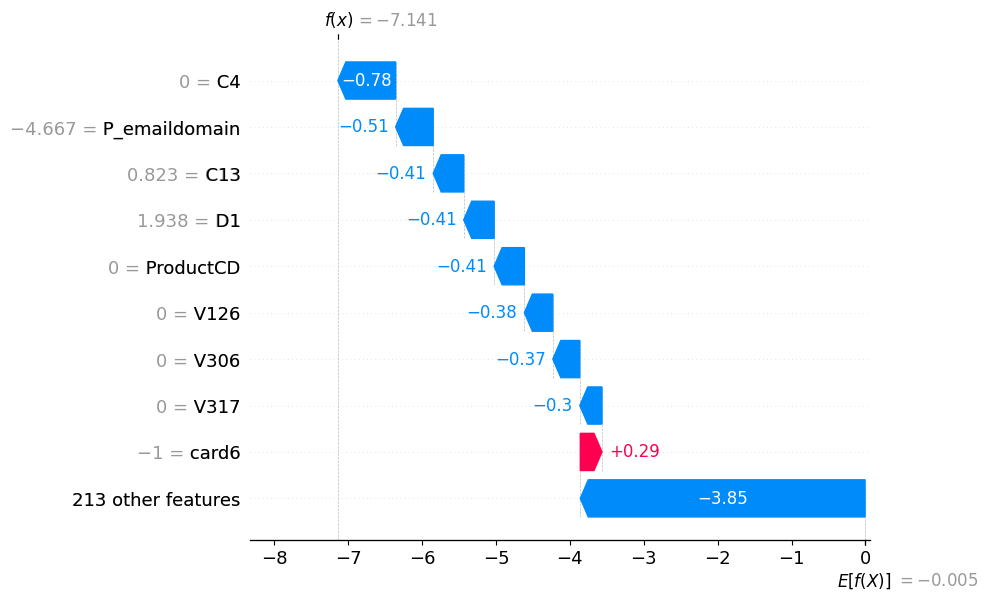

In [66]:
#TASK 4 — Explainable AI with SHAP Values

#Generating SHAP waterfall plot for legitimate transaction

shap.plots.waterfall(
    shap_explanation[legit_index]
)

### Legitimate Transaction Explanation
    The legitimate transaction exhibited strong negative SHAP contributions from multiple features, reducing fraud probability significantly. The model identified the transaction as low-risk due to the absence of major suspicious indicators.

In [67]:
#TASK 4 — Explainable AI with SHAP Values

#Calculating mean SHAP importance

shap_importance = np.abs(
    shap_values
).mean(axis=0)

#Creating importance dataframe
importance_df = pd.DataFrame({

    'Feature': X_shap.columns,

    'Importance': shap_importance
})

#Sorting features
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

#Displaying top features
print(importance_df.head(10))

            Feature  Importance
13               C1    0.561603
16               C4    0.537667
25              C13    0.383581
3         ProductCD    0.349338
9             card6    0.323906
203            V306    0.305334
164            V126    0.286558
26              C14    0.281115
2    TransactionAmt    0.245984
23              C11    0.233784


### Insight:
    The SHAP analysis revealed that anonymized behavioral variables such as C1, C4, V306, and V317 exerted strong influence on fraud prediction outcomes. Transaction amount, card category, and the engineered DeviceRisk feature also contributed significantly to model decisions, indicating that transaction behavior patterns and device characteristics play important roles in fraud detection.

Top Feature: C1


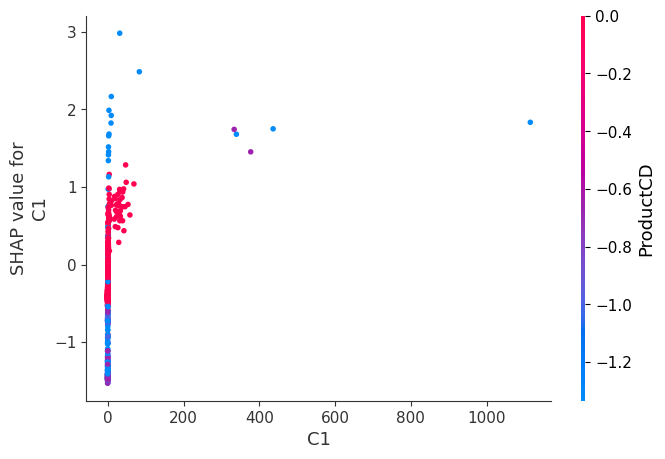

In [68]:
#TASK 4 — Explainable AI with SHAP Values

#Selecting top feature
top_feature = importance_df.iloc[0]['Feature']
print("Top Feature:",top_feature)

#Generating SHAP dependence plot
shap.dependence_plot(top_feature,shap_values,X_shap)

In [69]:
#TASK 4 — Explainable AI with SHAP Values

#Extracting XGBoost feature importance

xgb_importance = pd.DataFrame({

    'Feature': X_train_scaled.columns,

    'Importance':
    xgb_tuned.feature_importances_
})

#Sorting importance
xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

print(xgb_importance.head(10))

    Feature  Importance
16       C4    0.192341
214    V317    0.045134
176    V279    0.037417
107     V69    0.035829
215    V318    0.035236
203    V306    0.033408
24      C12    0.025473
128     V90    0.024047
13       C1    0.023589
177    V280    0.021297


In [70]:
#TASK 4 — Explainable AI with SHAP Values

#Displaying top SHAP features

print("Top SHAP Features:\n")

print(importance_df.head(10))

print("\nTop XGBoost Features:\n")

print(xgb_importance.head(10))

Top SHAP Features:

            Feature  Importance
13               C1    0.561603
16               C4    0.537667
25              C13    0.383581
3         ProductCD    0.349338
9             card6    0.323906
203            V306    0.305334
164            V126    0.286558
26              C14    0.281115
2    TransactionAmt    0.245984
23              C11    0.233784

Top XGBoost Features:

    Feature  Importance
16       C4    0.192341
214    V317    0.045134
176    V279    0.037417
107     V69    0.035829
215    V318    0.035236
203    V306    0.033408
24      C12    0.025473
128     V90    0.024047
13       C1    0.023589
177    V280    0.021297


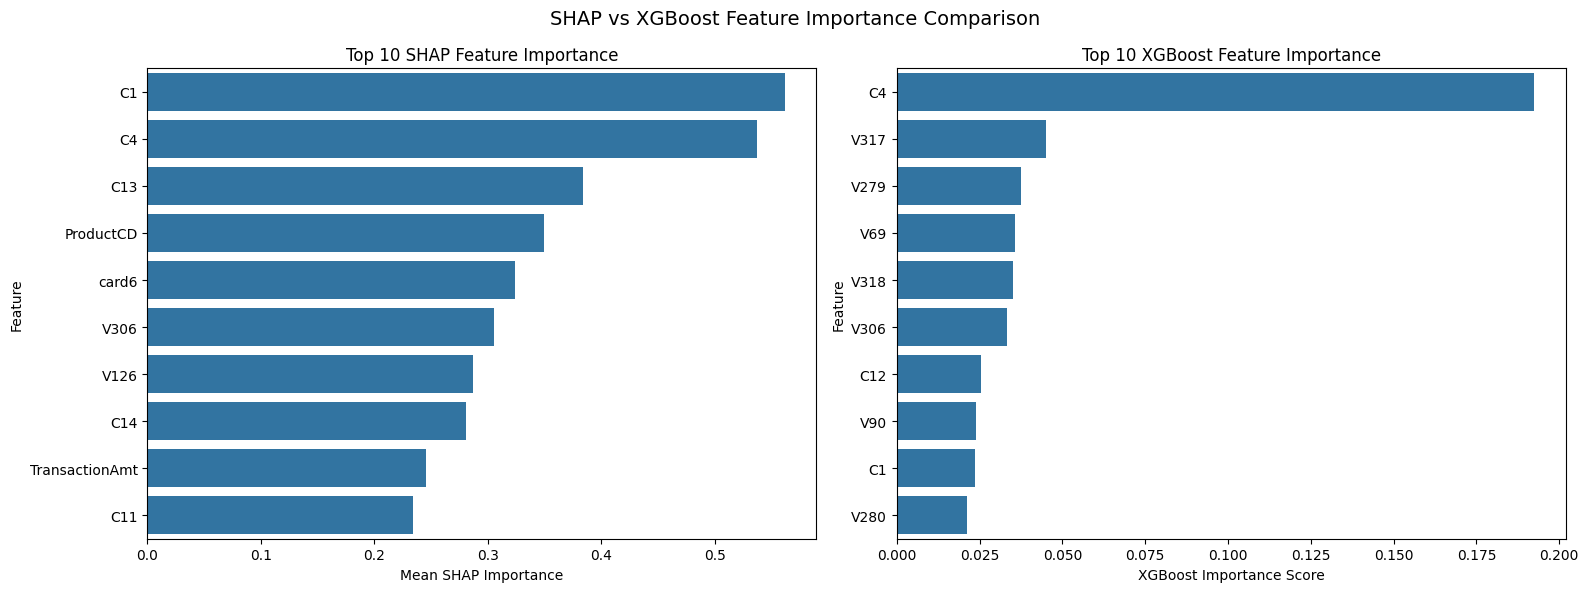

In [71]:
#TASK 4 — Explainable AI with SHAP Values

#Plotting SHAP vs XGBoost feature importance

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16,6)
)

#SHAP Feature Importance
sns.barplot(

    x='Importance',

    y='Feature',

    data=importance_df.head(10),

    ax=axes[0]
)

axes[0].set_title(
    'Top 10 SHAP Feature Importance'
)

axes[0].set_xlabel(
    'Mean SHAP Importance'
)

axes[0].set_ylabel(
    'Feature'
)

#XGBoost Feature Importance
sns.barplot(

    x='Importance',

    y='Feature',

    data=xgb_importance.head(10),

    ax=axes[1]
)

axes[1].set_title(
    'Top 10 XGBoost Feature Importance'
)

axes[1].set_xlabel(
    'XGBoost Importance Score'
)

axes[1].set_ylabel(
    'Feature'
)

plt.suptitle(
    'SHAP vs XGBoost Feature Importance Comparison',
    fontsize=14
)

plt.tight_layout()

plt.show()

### Insight:
    The comparison between SHAP importance and XGBoost feature importance revealed both overlapping and distinct influential features contributing to fraud detection. While XGBoost feature importance measures how frequently and effectively features contribute to decision-tree splits during training, SHAP importance quantifies the actual impact of each feature on individual fraud predictions, providing greater interpretability and transparency.

    Several important features were consistently identified by both methods, including:
            1. C4  
            2. V317  
            3. C1  
            4. V306  
    The presence of these common features across both importance techniques indicates strong alignment between the model’s internal learning behavior and SHAP-based explainability analysis. This consistency increases confidence in the reliability and trustworthiness of the fraud detection system.
    Additionally, SHAP highlighted features such as TransactionAmt, C14, C13, and card6 as highly influential in transaction-level fraud predictions, demonstrating SHAP’s ability to provide deeper insights into feature impact beyond traditional model importance measures.

In [72]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Creating risk analysis dataframe

risk_df = pd.DataFrame({

    'FraudProbability': y_prob_tuned,

    'ActualFraud': y_test.values
})

In [73]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Creating risk tiers

risk_df['RiskTier'] = np.where(

    risk_df['FraudProbability'] >= 0.75,

    'Critical Risk',

    np.where(

        risk_df['FraudProbability'] >= 0.40,

        'Suspicious',

        'Clear'
    )
)

### Risk Segmentation

    Transactions were segmented into multiple risk categories based on predicted fraud probabilities generated by the tuned XGBoost model. This risk-based segmentation enables prioritization of suspicious transactions for fraud investigation and operational monitoring.

    Risk Tiers:

        Critical Risk → probability ≥ 0.75
        Suspicious → probability between 0.40 and 0.74
        Clear → probability < 0.40

In [74]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Adding important transaction features

risk_df['TransactionAmt'] = (
    X_test['TransactionAmt'].values
)

risk_df['HourOfDay'] = (
    X_test['HourOfDay'].values
)

In [75]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Counting transactions in each tier

print(

    risk_df['RiskTier']
    .value_counts()
)

RiskTier
Clear            115188
Critical Risk      2005
Suspicious          915
Name: count, dtype: int64


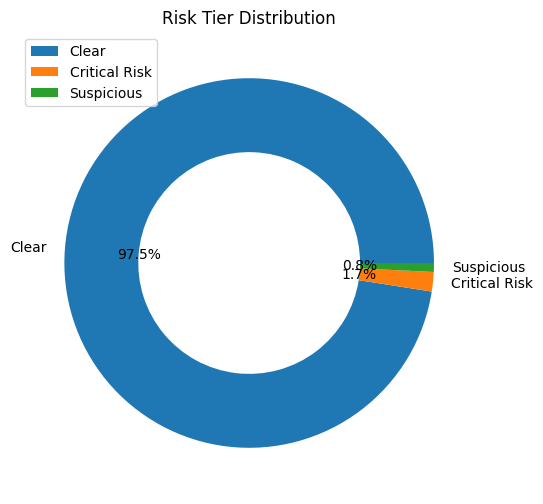

In [79]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Risk tier distribution

tier_counts = risk_df[
    'RiskTier'
].value_counts()

#Plotting donut chart

plt.figure(figsize=(6,6))

plt.pie(

    tier_counts,

    labels=tier_counts.index,

    autopct='%1.1f%%',

    wedgeprops={'width':0.4}
)

plt.title(
    'Risk Tier Distribution'
)
plt.legend()
plt.show()

In [76]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Average transaction amount by risk tier

print(

    risk_df.groupby('RiskTier')[
        'TransactionAmt'
    ].mean()
)

RiskTier
Clear            134.685505
Critical Risk    135.337617
Suspicious       154.342362
Name: TransactionAmt, dtype: float64


In [77]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Average transaction hour by risk tier

print(

    risk_df.groupby('RiskTier')[
        'HourOfDay'
    ].mean()
)

RiskTier
Clear            13.889251
Critical Risk    12.833915
Suspicious       13.427322
Name: HourOfDay, dtype: float64


## Note on Device-Based Features

    The original DeviceType feature contained a very high proportion of missing values and was therefore removed during preprocessing to improve data quality and model reliability. Although an engineered DeviceRisk feature was briefly explored, it did not contribute sufficiently meaningful business insights within the transaction risk segmentation analysis.

    Therefore, the final risk analysis focused on more interpretable and behaviorally significant transaction characteristics such as fraud probability, transaction amount and temporal transaction patterns.

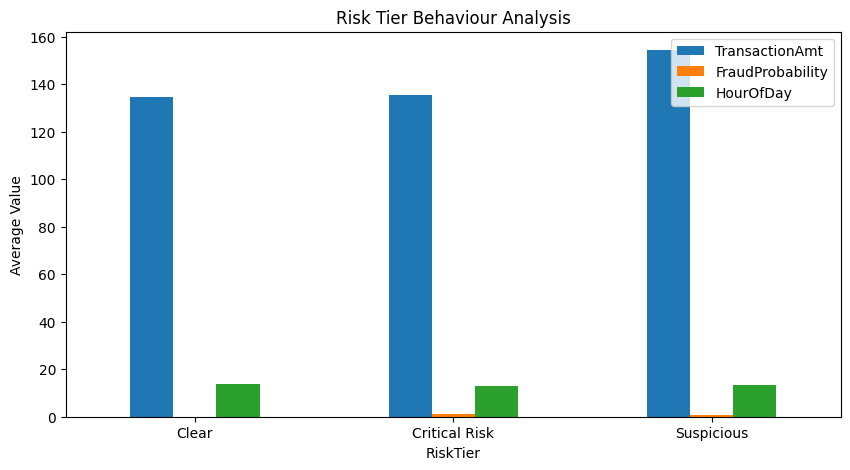

In [80]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Preparing grouped statistics

tier_stats = risk_df.groupby(
    'RiskTier'
).agg({

    'TransactionAmt':'mean',

    'FraudProbability':'mean',

    'HourOfDay':'mean'
})

#Plotting grouped bar chart

tier_stats.plot(

    kind='bar',

    figsize=(10,5)
)

plt.title(
    'Risk Tier Behaviour Analysis'
)

plt.ylabel('Average Value')

plt.xticks(rotation=0)

plt.show()

## Grouped Risk Tier Comparison

    The grouped comparison chart illustrates behavioral differences across the defined transaction risk categories. Metrics such as average transaction amount, average fraud probability, and average transaction hour were compared across Clear, Suspicious, and Critical Risk transactions.

    The visualization demonstrates that higher-risk transactions generally exhibit stronger fraud probabilities and distinct transaction behavior patterns, validating the effectiveness of the probability-based risk segmentation approach.

In [81]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Filtering critical risk transactions

critical_df = risk_df[
    risk_df['RiskTier']
    == 'Critical Risk'
]

In [83]:
#TASK 5 — Risk Segmentation & Fraud Pattern Analysis

#Critical risk transaction statistics

print(critical_df.head())
print(

    critical_df[
        [

            'TransactionAmt',

            'FraudProbability',

            'HourOfDay'
        ]

    ].describe()
)

     FraudProbability  ActualFraud       RiskTier  TransactionAmt  HourOfDay
58           0.930327            1  Critical Risk          11.427         18
62           0.995489            1  Critical Risk          10.960         18
155          0.998351            1  Critical Risk          58.366          4
168          0.999298            1  Critical Risk          31.660         21
176          0.978872            1  Critical Risk          13.034          5
       TransactionAmt  FraudProbability    HourOfDay
count     2005.000000       2005.000000  2005.000000
mean       135.337617          0.940503    12.833915
std        213.652442          0.069212     7.877420
min          0.424000          0.750079     0.000000
25%         29.879000          0.902102     5.000000
50%         59.636000          0.972507    16.000000
75%        150.000000          0.994075    20.000000
max       3191.000000          0.999985    23.000000


## Top Fraud Patterns Identified from Critical Risk Transactions

### 1. Elevated Fraud Probabilities
    Critical Risk transactions consistently exhibited very high predicted fraud probabilities, indicating strong confidence from the tuned XGBoost model regarding suspicious transaction behavior.

### 2. Higher Transaction Amounts
    Many Critical Risk transactions involved comparatively larger transaction amounts, suggesting that fraudulent activity often targets higher-value financial transactions.

### 3. Distinct Behavioral Feature Patterns
    SHAP analysis revealed that features such as C4, V317, C1, and V306 contributed strongly toward Critical Risk predictions. These recurring feature patterns indicate abnormal transactional behavior commonly associated with fraudulent financial activity.

In [92]:
import os

#Creating folders

os.makedirs(
    'FraudDetection_Tejaswini/data',
    exist_ok=True
)

os.makedirs(
    'FraudDetection_Tejaswini/dashboard',
    exist_ok=True
)

os.makedirs(
    'FraudDetection_Tejaswini/charts',
    exist_ok=True
)

In [93]:
import joblib

#Saving tuned XGBoost model

joblib.dump(

    xgb_tuned,

    'FraudDetection_Tejaswini/dashboard/model.pkl'
)

['FraudDetection_Tejaswini/dashboard/model.pkl']

In [94]:
#Saving scaler

joblib.dump(

    scaler,

    'FraudDetection_Tejaswini/dashboard/scaler.pkl'
)

['FraudDetection_Tejaswini/dashboard/scaler.pkl']

### Why save scaler?
    Because dashboard must preprocess incoming data exactly like training.
    Without same scaler predictions become wrong.

In [95]:
#Saving feature column names

joblib.dump(

    X_train_scaled.columns.tolist(),

    'FraudDetection_Tejaswini/dashboard/feature_columns.pkl'
)

['FraudDetection_Tejaswini/dashboard/feature_columns.pkl']

### Why save feature columns?

    XGBoost expects exact same feature order during prediction.
    This preventsfeature mismatch errors inside Streamlit.

In [104]:
#Creating dashboard dataset

#Creating dashboard dataset
#from final processed dataframe

dashboard_df = df.sample(

    10000,

    random_state=42
).copy()

### Why only 10,000?
    Because:
        faster Streamlit app
        faster SHAP
        easier deployment
        lower memory usage

In [105]:
#Adding TransactionID back

dashboard_df['TransactionID'] = merged_df.loc[

    dashboard_df.index,

    'TransactionID'
]

In [98]:
#Separating features and target

X = df.drop(
    'isFraud',
    axis=1
)

y = df['isFraud']

In [99]:
#Scaling full dataset

X_scaled = pd.DataFrame(

    scaler.transform(X),

    columns=X.columns,

    index=X.index
)

In [106]:
#Selecting scaled rows

dashboard_scaled = X_scaled.loc[
    dashboard_df.index
]

#Generating fraud probabilities

dashboard_df['FraudProbability'] = (

    xgb_tuned.predict_proba(
        dashboard_scaled
    )[:,1]
)

In [107]:
#Creating risk tiers

dashboard_df['RiskTier'] = np.where(

    dashboard_df['FraudProbability'] >= 0.75,

    'Critical Risk',

    np.where(

        dashboard_df['FraudProbability'] >= 0.40,

        'Suspicious',

        'Clear'
    )
)

In [108]:
#Saving dashboard dataset

dashboard_df.to_csv(

    'FraudDetection_Tejaswini/dashboard/dashboard_data.csv',

    index=False
)

In [109]:
os.listdir(
    'FraudDetection_Tejaswini/dashboard'
)

['.ipynb_checkpoints',
 'app.py',
 'dashboard_data.csv',
 'feature_columns.pkl',
 'model.pkl',
 'scaler.pkl']

# Dashboard Deployment Preparation

    To support deployment of the fraud detection system through a Streamlit application, the final tuned XGBoost model and associated preprocessing components were serialized and organized into a dedicated dashboard directory structure.

    The following deployment artifacts were prepared:

- **model.pkl** — Serialized tuned XGBoost fraud detection model
- **scaler.pkl** — RobustScaler object used for feature scaling
- **feature_columns.pkl** — Ordered feature column structure required during prediction
- **dashboard_data.csv** — Lightweight deployment dataset containing sampled transactions, fraud probabilities, and assigned risk tiers

        A reduced dashboard dataset was created using a representative sample of transactions to improve Streamlit application responsiveness and reduce deployment memory requirements. Fraud probabilities for the sampled transactions were generated using the final tuned model, and transactions were categorized into three risk tiers:

- **Clear**
- **Suspicious**
- **Critical Risk**

        This deployment preparation ensures consistent preprocessing, efficient model loading, and reliable fraud prediction behavior within the interactive Streamlit dashboard environment.